# [실습] LangChain으로 데이터 생성하기




이번 실습에서는 Continuous Pretrain과 Instruction Tuning을 위한 데이터 생성에 대해 알아보겠습니다.



In [3]:
!pip install langchain langchain-community langchain-openai langchain-ollama


[notice] A new release of pip is available: 25.0.1 -> 25.2
[notice] To update, run: python -m pip install --upgrade pip


In [7]:
from langchain.prompts import PromptTemplate
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain.prompts import ChatPromptTemplate
from langchain.prompts import FewShotPromptTemplate
from langchain.schema.output_parser import StrOutputParser

In [8]:
import os
import json
from dotenv import load_dotenv

load_dotenv('.env',override=True)

True

# LLM 설정하기

무료 API: Gemini를 사용하는 경우 분당 10회 제한을 고려하여 Rate Limiter를 설정합니다.

In [ ]:
from langchain_core.rate_limiters import InMemoryRateLimiter
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_openai import ChatOpenAI


# rate limiter를 LLM에 적용
llm = ChatOpenAI(
    model="gpt-4.1",
    temperature=0,
)

In [10]:
llm.invoke("안녕")

AIMessage(content='안녕하세요! 무엇을 도와드릴까요? 😊', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 12, 'prompt_tokens': 9, 'total_tokens': 21, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4.1-2025-04-14', 'system_fingerprint': 'fp_3502f4eb73', 'id': 'chatcmpl-CCU6Ddmwa28uFPO7e52v3bTBRAA0d', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='run--16816002-ee7d-4e5c-a930-ec4d27d19352-0', usage_metadata={'input_tokens': 9, 'output_tokens': 12, 'total_tokens': 21, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}})

## 도메인 코퍼스 만들기

Continous Pretraining을 위한 Corpus를 생성합니다.   
코퍼스는 지식 학습에 매우 중요한 역할을 수행하며, 정확성이 매우 중요하기 때문에   
일반적으로는 API, 외부 자료 수집 등을 통해 구성하는 것이 효과적입니다.

In [12]:
try:
    disease_list = open('./disease_list.txt','r').read().strip().split(',')
except:
    search_prompt = '''
사회 취약 계층을 위한 의료 정보 책자를 만들고자 합니다.
해당 책자에는 다양한 질환의 정의와 증상, 치료 방법, 이후의 관리 방법이 포함됩니다.
자료 수집을 위해, 대표적인 10개의 질환 목록을 선정하세요.
각 단어의 한국어 명칭을 , 로 구분하여 나열해 주세요. 예시: 단어1, 단어2, ... 단어10
단어 이외의 다른 내용은 출력하지 마세요.
한글 명칭만 작성하세요.
'''
    disease_list = llm.invoke(search_prompt).content.split(', ')
    with open('disease_list.txt','w') as f:
        f.write(','.join(disease_list))
    f.close()

In [13]:
len(disease_list)

10

In [14]:
disease_list

['고혈압', '당뇨병', '심근경색', '뇌졸중', '폐렴', '결핵', '치매', '우울증', '관절염', '암']

생성된 질환에 대해, 세부 사항을 작성하기 위한 카테고리를 구성합니다.

In [ ]:
from langchain.prompts import ChatPromptTemplate
from itertools import product
from typing import List, Dict
import json
from tqdm import tqdm  # 진행상황 표시용
from datetime import datetime
import time

# 카테고리 옵션 정의
category_options = {
   # 문서 주제 분류
   'document_type': [
      # 일반 소개 관련
      'Symptoms', # 증상
      'General Information', # 일반 정보
      'Frequently Asked Questions', # 자주 묻는 질문

       # 약물치료 관련
       'Drug types and mechanisms',        # 약물 종류와 작용기전
       'Administration and precautions',   # 투약 방법과 주의사항
       'Side effects management',          # 부작용 관리

       # 수술 관련
       'Surgical indications',             # 수술 적응증
       'Procedure overview',               # 수술 과정 개요
       'Post-operative care',              # 수술 후 관리

       # 생활습관 관련
       'Diet and exercise',                # 식이요법과 운동
       'Daily life management',            # 일상생활 관리
       'Prevention guidelines',            # 예방 지침

       # 진단과 치료계획 관련
       'Diagnostic process',               # 진단 과정
       'Treatment strategy',               # 치료 전략
       'Progress monitoring',              # 경과 관찰
            
   ],

   # 상세도 수준 다양화
   'level': ['Standard', 'Expert', 'For Elderly (easy to understand)']    
}

450

Combination의 개수를 구합니다.

In [ ]:
combinations = list(product(disease_list, category_options['document_type'], category_options['level']))
len(combinations)

In [17]:
arguments = [{'disease':x[0],'document_type':x[1],'level':x[2]} for x in combinations]
arguments[0]

{'disease': '고혈압', 'document_type': 'Symptoms', 'level': 'Standard'}

이제, 생성 프롬프트 체인을 만들고 배치로 실행합니다.

In [18]:
from langchain_core.runnables import RunnablePassthrough, RunnableParallel

medical_prompt = ChatPromptTemplate([
   ('system', '''You are a medical professor creating training data for healthcare AI development.

Core Principle: Each document must be self-contained and complete within its specific scope.

Writing Guidelines:
- Maintain medical accuracy while emphasizing logical flow
- Include evidence-based, up-to-date medical knowledge
- When using medical terms, include explanations in parentheses
- Write output in Korean language with clear and precise explanations
- Focus on information relevant to vulnerable populations
- Write comprehensive content within your assigned scope
- Use natural medical language without artificial boundaries

Document Type Focus - Write ONLY about:

1. **Drug types and mechanisms**: Pharmacological classifications, receptor mechanisms, metabolic pathways, drug action principles
2. **Administration and precautions**: Dosing schedules, administration routes, drug interactions, contraindications, timing considerations
3. **Side effects management**: Adverse event identification, severity assessment, management protocols, when to discontinue
4. **Surgical indications**: Surgical criteria, risk-benefit analysis, timing decisions, patient selection factors
5. **Procedure overview**: Surgical techniques, anesthesia types, procedural steps, equipment and technology used
6. **Post-operative care**: Wound management, pain control, activity progression, complication monitoring
7. **Diet and exercise**: Nutritional requirements, food restrictions, exercise prescriptions, activity modifications
8. **Daily life management**: Work adaptations, home environment modifications, assistive devices, social considerations
9. **Prevention guidelines**: Risk factor modification, screening protocols, preventive medications, lifestyle interventions
10. **Diagnostic process**: Test selection, diagnostic criteria, differential diagnosis, result interpretation
11. **Treatment strategy**: Treatment algorithms, therapy selection criteria, combination approaches, escalation protocols
12. **Progress monitoring**: Follow-up intervals, monitoring parameters, outcome measurements, treatment response criteria
13. **Frequently Asked Questions**: Common misconceptions, practical concerns, cost considerations, healthcare access
14. **General Introduction**: Disease definition, epidemiology, pathophysiology, natural history, disease burden

Remember:
- Each document should be complete and informative within its designated scope
- Write for medically vulnerable populations with clear explanations
- All content must be written in Korean language
- Focus exclusively on your document type without mentioning other aspects'''),

   ('user', '''Please write comprehensive medical content about {disease}.
Document type: {document_type}
Detail level: {level}

Create a thorough, naturally flowing medical document that completely covers this specific aspect of {disease}.
Ensure the content is self-contained and professionally written.
Please write the entire response in Korean.''')
])

llm_chain = medical_prompt | llm | StrOutputParser()

generate_chain = RunnableParallel(metadata = RunnablePassthrough(), result = llm_chain)

# generated_corpus = generate_chain.batch(arguments[0:2])

In [ ]:
import json
from datetime import datetime
import time

# 배치 크기 설정 (API 제한 고려)
BATCH_SIZE = 30  # 한 번에 처리할 개수
generated_corpus = []
failed_items = []

# 전체 조합을 배치로 나누기
batches = [combinations[i:i+BATCH_SIZE] for i in range(0, len(combinations), BATCH_SIZE)]

# 진행상황 표시하며 처리
for batch_idx, batch in enumerate(tqdm(batches, desc="Processing batches")):
    try:
        # 각 배치의 arguments 준비
        batch_args = [
            {
                'disease': disease,
                'document_type': doc_type,
                'level': level
            }
            for disease, doc_type, level in batch
        ]
        
        # 배치 처리
        results = generate_chain.batch(batch_args)
        
        # 결과에 인덱스 추가하여 저장
        for (disease, doc_type, level), result in zip(batch, results):
            generated_corpus.append({
                'index': len(generated_corpus),
                'disease': disease,
                'document_type': doc_type,
                'level': level,
                'content': result['result'],
                'metadata': result['metadata'],
                'timestamp': datetime.now().isoformat()
            })
        
        # 중간 저장 (3번 배치마다)
        if (batch_idx + 1) % 3 == 0:
            with open(f'corpus_checkpoint_{batch_idx+1}.json', 'w', encoding='utf-8') as f:
                json.dump(generated_corpus, f, ensure_ascii=False, indent=2)
            print(f"Checkpoint saved: {len(generated_corpus)} documents")
            
    except Exception as e:
        print(f"Error in batch {batch_idx}: {e}")
        failed_items.extend(batch)
        continue
    
    # API 제한 방지용 대기
    time.sleep(1)

# 최종 결과 저장
with open('medical_corpus_result.json', 'w', encoding='utf-8') as f:
    json.dump({
        'total_documents': len(generated_corpus),
        'generation_date': datetime.now().isoformat(),
        'failed_items': len(failed_items),
        'documents': generated_corpus
    }, f, ensure_ascii=False, indent=2)

print(f"완료: {len(generated_corpus)}개 생성, {len(failed_items)}개 실패")

Processing batches:  60%|██████    | 9/15 [11:10<06:32, 65.40s/it] 

Checkpoint saved: 300 documents


Processing batches: 100%|██████████| 15/15 [26:05<00:00, 104.39s/it]

완료: 450개 생성, 0개 실패


생성된 데이터를 확인해 보겠습니다.

In [1]:
import json

with open ("medical_corpus_result.json", "r", encoding='utf-8') as f:
    data = json.load(f)
len(data['documents'])

450

In [2]:
data['documents'][292]

{'index': 292,
 'disease': '치매',
 'document_type': 'Procedure overview',
 'level': 'Expert',
 'content': '치매의 시술적 접근 개요\n\n치매는 주로 약물치료와 비약물적 중재가 중심이지만, 일부 환자에서는 시술적(수술적) 치료가 고려될 수 있습니다. 본 문서에서는 치매 환자에서 적용 가능한 시술적 치료법의 종류, 적응증, 시술 과정, 사용되는 장비 및 기술, 마취 방법, 시술 단계 등을 체계적으로 설명합니다.\n\n1. 뇌심부자극술(Deep Brain Stimulation, DBS)\n\n1) 개요  \n뇌심부자극술은 전극을 뇌의 특정 부위(주로 시상하부, 해마, 기저핵 등)에 삽입하여 전기적 자극을 가하는 시술입니다. 주로 파킨슨병, 진전증 등 운동장애 질환에서 사용되어 왔으나, 최근 알츠하이머병 등 치매 환자에서 인지기능 개선을 목적으로 연구되고 있습니다.\n\n2) 적응증  \n- 약물치료에 반응이 미미한 중등도 치매 환자  \n- 비교적 젊은 연령(65세 미만)  \n- 뇌 영상에서 중증 위축이나 뇌혈관질환이 없는 경우  \n- 전신마취에 견딜 수 있는 신체 상태\n\n3) 시술 과정  \n- 시술 전 MRI, CT 등 영상검사로 목표 부위 결정  \n- 국소마취 또는 경증 진정하에 두개골에 작은 구멍을 내고, 미세전극을 목표 부위에 삽입  \n- 전기자극에 대한 반응을 실시간으로 확인  \n- 전극이 적절히 위치하면, 전극을 두피 아래로 연결하여 흉부에 삽입한 자극기(펄스 발생기)와 연결  \n- 시술 후 자극기 세팅 및 조정\n\n4) 사용 장비 및 기술  \n- 뇌정위 프레임(stereotactic frame)  \n- 미세전극 및 자극기  \n- 실시간 영상유도장치(MRI, CT)  \n- 신경생리학적 모니터링 장비\n\n5) 마취 방법  \n- 주로 국소마취와 경증 진정(sedation)  \n- 일부 환자에서는 전신마취 필요\n\n6) 시술 단계  \n- 두개골

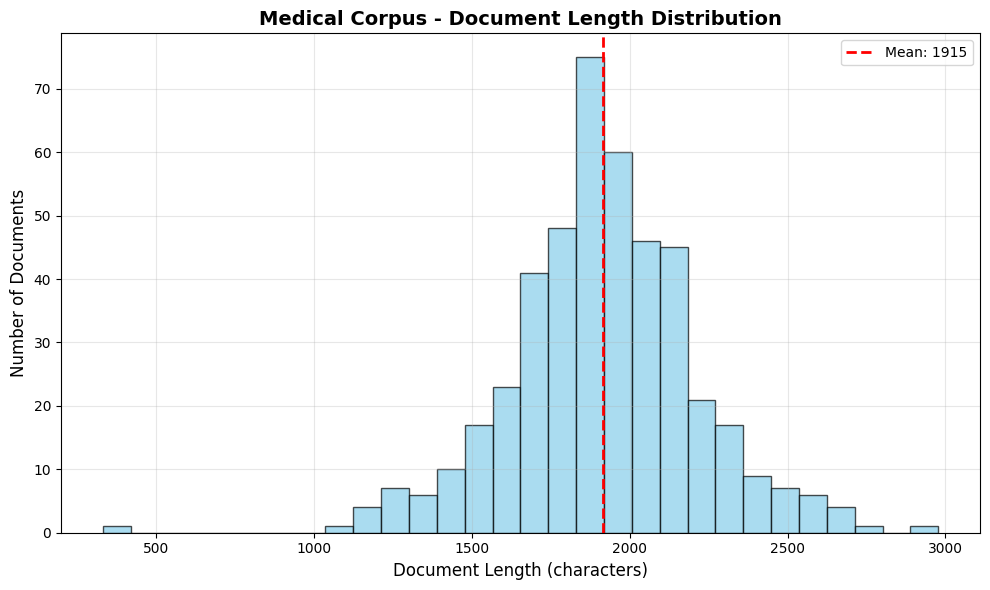

Total documents: 450
Average length: 1915 characters


In [3]:
import matplotlib.pyplot as plt
content_lengths = [len(doc['content']) 
                  for doc in data['documents'] 
                  if 'content' in doc and doc['content']]

# 히스토그램 그리기
plt.figure(figsize=(10, 6))
plt.hist(content_lengths, bins=30, color='skyblue', edgecolor='black', alpha=0.7)
plt.title('Medical Corpus - Document Length Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Document Length (characters)', fontsize=12)
plt.ylabel('Number of Documents', fontsize=12)
plt.grid(True, alpha=0.3)

# 평균선 추가
mean_length = sum(content_lengths) / len(content_lengths)
plt.axvline(mean_length, color='red', linestyle='dashed', linewidth=2, label=f'Mean: {mean_length:.0f}')
plt.legend()

plt.tight_layout()
plt.show()

print(f"Total documents: {len(content_lengths)}")
print(f"Average length: {mean_length:.0f} characters")

In [7]:
for doc in data['documents']:
    if len(doc['content']) > 2800:
        print(doc)

{'index': 52, 'disease': '당뇨병', 'document_type': 'Frequently Asked Questions', 'level': 'Expert', 'content': '당뇨병 자주 묻는 질문(FAQ)\n\n1. 당뇨병이란 무엇인가요?  \n당뇨병은 혈액 내 포도당(혈당) 수치가 만성적으로 높아지는 대사 질환입니다. 인슐린(췌장에서 분비되는 혈당 조절 호르몬)의 분비 또는 작용에 이상이 생겨 발생합니다. 대표적으로 제1형(인슐린 분비 결핍)과 제2형(인슐린 저항성 및 상대적 결핍)이 있습니다.\n\n2. 당뇨병의 주요 증상은 무엇인가요?  \n초기에는 증상이 없을 수 있으나, 다음과 같은 증상이 나타날 수 있습니다:  \n- 잦은 소변(다뇨)  \n- 심한 갈증(다갈)  \n- 체중 감소  \n- 피로감  \n- 시야 흐림  \n- 상처 치유 지연  \n고령자, 만성질환자 등 취약계층에서는 증상이 뚜렷하지 않을 수 있으므로 정기적인 검진이 중요합니다.\n\n3. 당뇨병은 어떻게 진단하나요?  \n진단은 다음과 같은 혈액검사로 이뤄집니다:  \n- 공복 혈당(8시간 금식 후 측정): 126mg/dL 이상  \n- 경구 당부하검사(OGTT) 2시간 후 혈당: 200mg/dL 이상  \n- 당화혈색소(HbA1c): 6.5% 이상  \n- 임의 혈당: 200mg/dL 이상(증상 동반 시)  \n진단 기준은 한 번의 검사로 확정하지 않고, 필요시 반복 측정합니다.\n\n4. 당뇨병은 완치가 가능한가요?  \n현재로서는 완치가 어렵지만, 적절한 치료와 생활습관 개선을 통해 혈당을 정상 범위로 조절하고 합병증을 예방할 수 있습니다. 일부 제2형 당뇨병 환자는 체중 감량, 식이조절, 운동 등으로 약물 없이도 혈당을 조절할 수 있습니다.\n\n5. 당뇨병의 주요 합병증은 무엇인가요?  \n장기적으로 혈당이 높으면 다음과 같은 합병증 위험이 증가합니다:  \n- 미세혈관 합병증: 망막병증(실명 위험), 신장병증(신부전), 신경병증(감각 저하, 통증) 

생성된 Corpus는 이후 Continuous Pretraining 실습에 사용할 수 있습니다.

API 호출 메타데이터를 제거하고, 파일로 저장합니다.

In [8]:
with open('medical_corpus.json', 'w', encoding='utf-8') as f:
    json.dump(data['documents'], f, ensure_ascii=False, indent=2)

print('medical corpus 생성 완료')

medical corpus 생성 완료
